In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
sys.path.append('../../codes/library/')

import scipy.special as sc
from mf_lib import*
from mf_plotting import*

plt.rcParams['text.usetex'] = True
Text_files_path = '/Users/robertomorantovar/Dropbox/Research/Immune_system/'
plt.style.use("seaborn-v0_8-colorblind")
fig_kw = dict(figsize=(8 * 1.62, 8), gridspec_kw={'left': .12, 'right': .95, 'bottom': .15, 'top': .94})

%autosave 60

Autosaving every 60 seconds


In [2]:
def compute_circles(a, gap, n=5):
    """
    Compute centers and radii for n circles where:
    - Radii follow r_i = (i+1)^{-a} for i = 0, 1, ..., n-1
    - All centers share the same y-coordinate (y=0)
    - The gap between the borders of consecutive circles is constant
    
    Parameters
    ----------
    a : float
        Power-law exponent (positive). Radius of circle i is (i+1)^{-a}.
    gap : float
        Distance between the border of consecutive circles.
    n : int
        Number of circles.
    
    Returns
    -------
    centers_x : array of x-coordinates of circle centers
    radii : array of radii
    """
    radii = np.flip([(i + 1) ** (-a) for i in range(n)])

    # Place the first circle at x = 0
    centers_x = np.zeros(n)
    for i in range(1, n):
        # Right border of circle i-1: centers_x[i-1] + radii[i-1]
        # Left border of circle i:    centers_x[i]   - radii[i]
        # We want:  left_border_i - right_border_{i-1} = gap
        centers_x[i] = centers_x[i - 1] + radii[i - 1] + gap + radii[i]

    return centers_x, radii


def plot_circles(a=0.5, gap=0.2, n=5, c = 0, colors = 0):
    centers_x, radii = compute_circles(a, gap, n)

    fig, ax = plt.subplots(figsize=(2*n, 4))

    for i in range(n):
        circle = plt.Circle(
            (centers_x[i], 0), radii[i],
            fill=True, linewidth=2, edgecolor=colors[c], facecolor = colors[c],
            alpha = (i+1)/(n), label=f"Circle {i+1}: r = {radii[i]:.3f}"
        )
        ax.add_patch(circle)
        # Mark the center
        # ax.plot(centers_x[i], 0, 'o', color=colors[i], markersize=3)

    # Draw gap annotations between consecutive circles
    # for i in range(n - 1):
    #     right_border = centers_x[i] + radii[i]
    #     left_border = centers_x[i + 1] - radii[i + 1]
    #     mid = (right_border + left_border) / 2
        # ax.annotate(
        #     '', xy=(left_border, 0), xytext=(right_border, 0),
        #     arrowprops=dict(arrowstyle='<->', color='red', lw=1.2)
        # )
        # ax.text(mid, -0.15, f"gap={gap}", ha='center', va='top',
        #         fontsize=7)#, color='red')

    # Axis settings
    pad = 0.2
    x_min = centers_x[0] - radii[0] - pad
    x_max = centers_x[-1] + radii[-1] + pad
    r_max = radii[-1]
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(-r_max - pad, r_max + pad)
    ax.set_aspect('equal')
    # ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
    # ax.set_title(f"5 Circles with radii $r_i = i^{{-a}}$,  $a = {a}$,  equal gap = {gap}")
    # ax.legend(loc='upper right', fontsize=8)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.savefig("circles_power_law.png", dpi=150, bbox_inches='tight')
    return fig, ax


In [ ]:
plt.style.use("seaborn-v0_8-colorblind")
# --- Adjust these parameters ---
n_plots = 10
colors = plt.cm.plasma(np.linspace(0, 1, n_plots))
# colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
a = 1.2     # power-law exponent
gap = 0.1   # constant gap between consecutive borders
n = 5       # number of circles
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_repertoire/'
os.makedirs(output_plot, exist_ok=True)
for i in range(n_plots):
    fig, ax = plot_circles(a=a, gap=gap, n=n, c = i, colors = colors);
    fig.savefig(output_plot + 'repertoire_3_%d.pdf'%i, bbox_inches='tight');
    fig.savefig(output_plot + 'repertoire_3_%d.png'%i, dpi=300, bbox_inches='tight', transparent=True);

In [ ]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
ax.plot(E, 2e9*np.exp(-(E-16)**2/(2*6)), color='grey', alpha = 0.5, lw = 5)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_naive.pdf', dpi=200, transparent=True);

In [ ]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
ax.bar(x= E-0.2, height=1e4*np.exp(-(E-(16-6))**2/(2*6)), width = .4, color='gray', alpha = 1.0)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_equilibrium.pdf', dpi=200, transparent=True);

In [ ]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
ax.bar(x= E[E<6]-0.2, height=5e2*np.exp(1.1*E[E<6]), width = 0.4, color='limegreen', alpha = 1.0)
# ax.bar(x= E[E<6]+0.2, height=5e4*np.exp(-(E[E<6]-(16-8))**2/(2*6)), width = 0.4, color='limegreen', alpha = 1.0)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_optimal.pdf', dpi=200, transparent=True);

In [ ]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
ax.bar(x= E[E<6]-0.2, height=5e2*np.exp(1.1*E[E<6]), width = 0.4, color='limegreen', alpha = 1.0)
ax.bar(x= E[E<6]+0.2, height=4e1*np.exp(1.9*E[E<6]), width = 0.4, color=my_brown, alpha = 1.0)
# ax.bar(x= E-0.2, height=1000*np.exp(-0.75*E), width = 0.4, color='limegreen', alpha = 1.0)
# ax.bar(x= E+0.2, height=50*np.exp(-0.3*E), width = 0.4, color=my_brown, alpha = 1.0)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_null.pdf', dpi=200, transparent=True);

In [ ]:
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
ax.bar(x= E[E<6]-0.2, height=5e2*np.exp(1.1*E[E<6]), width = 0.4, color='limegreen', alpha = 1.0)
# ax.bar(x= E-0.2, height=1000*np.exp(-0.75*E), width = 0.4, color='limegreen', alpha = 1.0)
ax.bar(x= E[E<6]+0.2, height=1e4*np.exp(-1.*E[E<6]), width = 0.4, color=my_blue, alpha = 1.0)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_memory.pdf', dpi=200, transparent=True);

In [ ]:
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
# ax.bar(x= E-0.2, height=1000*np.exp(-0.75*E), width = 0.4, color='limegreen', alpha = 1.0)
ax.bar(x= E[E<6]+0.2, height=1e4*np.exp(-1.*E[E<6]), width=0.4, color=my_blue, alpha = 1.0)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_memory_2.pdf', dpi=200, transparent=True);

In [ ]:
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
n_bars = 20
E = np.linspace(0, n_bars, n_bars+1)

fig, ax = plt.subplots(**fig_kw)
ax.bar(x= E, height=2e9*np.exp(-(E-16)**2/(2*6)), width = .4, color='grey', alpha = 0.5)
ax.bar(x= E[E<6]+0.2, height=1e4*np.exp(-1.*E[E<6]), width=0.4, color=my_blue, alpha = 1.0)
ax.bar(x= E[E<6]+0.2 + 2.5, height=1e4*np.exp(-1.*E[E<6]), width=0.4, color=my_cyan, alpha = 1.0)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=17)
fig.savefig(output_plot + 'potency_escape.pdf', dpi=200, transparent=True);

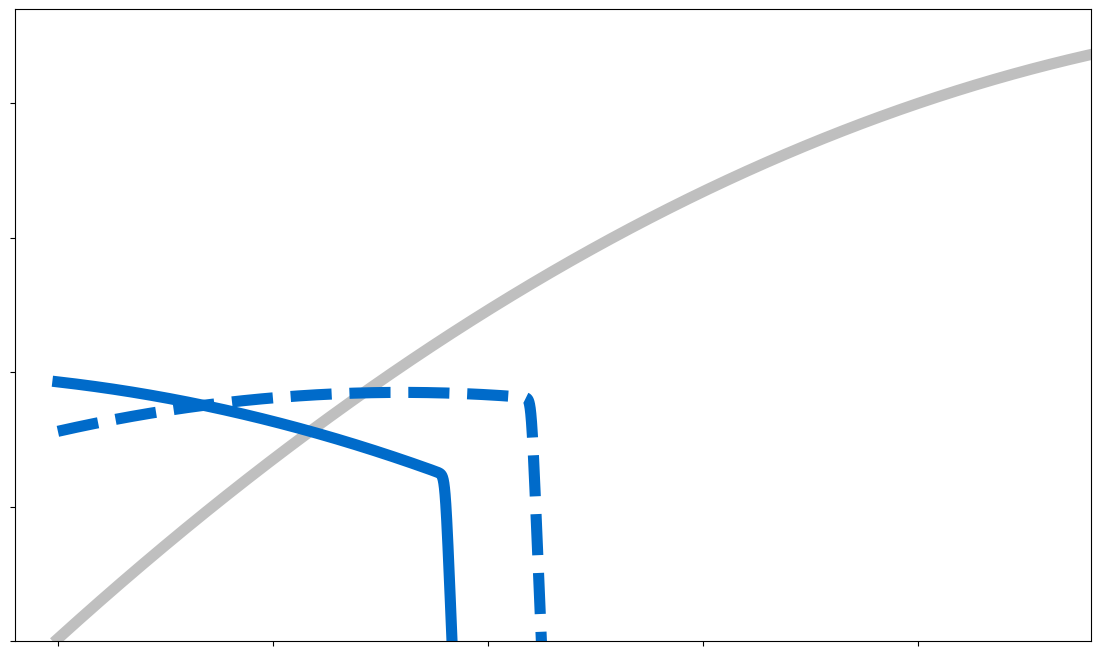

In [2]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
Emax = 12
E = np.linspace(0, Emax, 10000)
Ef = 5.5
Efm = 4.5
step = 70

fig, ax = plt.subplots(**fig_kw)
ax.plot(E, 2e9*np.exp(-(E-16)**2/(2*6)), color='grey', alpha = 0.5, lw = 8)
# ax.plot(E[E<(Ef+0.2)], 5e6*np.exp(-(E[E<(Ef+0.2)]-(16-4))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_brown, alpha = 0.9, lw = 8)
ax.plot(E[E<(Ef+0.2)], 5e3*np.exp(-(E[E<(Ef+0.2)]-(16-12))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_blue, alpha = 1.0, lw = 8, ls = '--')
ax.plot(E[E<(Efm+0.2)], 1e4*np.exp(-(E[E<(Efm+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Efm+0.2)] - Efm)))**-1, color=my_blue, alpha = 1.0, lw = 8)
# ax.plot(E[E<(Ef+0.2)] + 2.5, 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_cyan, alpha = 0.9, lw = 8)
# ax.plot(E[E<6] + 2.5, 1e4*np.exp(-1.*E[E<6]), color=my_cyan, alpha = 1.0, lw = 5)
# ax.set_xticks(np.linspace(0, Emax, Emax//2+1), [r"$%.1f$"%i for i in np.linspace(0, Emax, Emax//2+1)]);
ax.tick_params(axis='y', which='both', labelsize=44, labelleft=False)
ax.tick_params(axis='x', labelsize=44, labelbottom=False)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=Emax)
fig.savefig(output_plot + 'naive_memory.pdf', dpi=200, transparent=True);

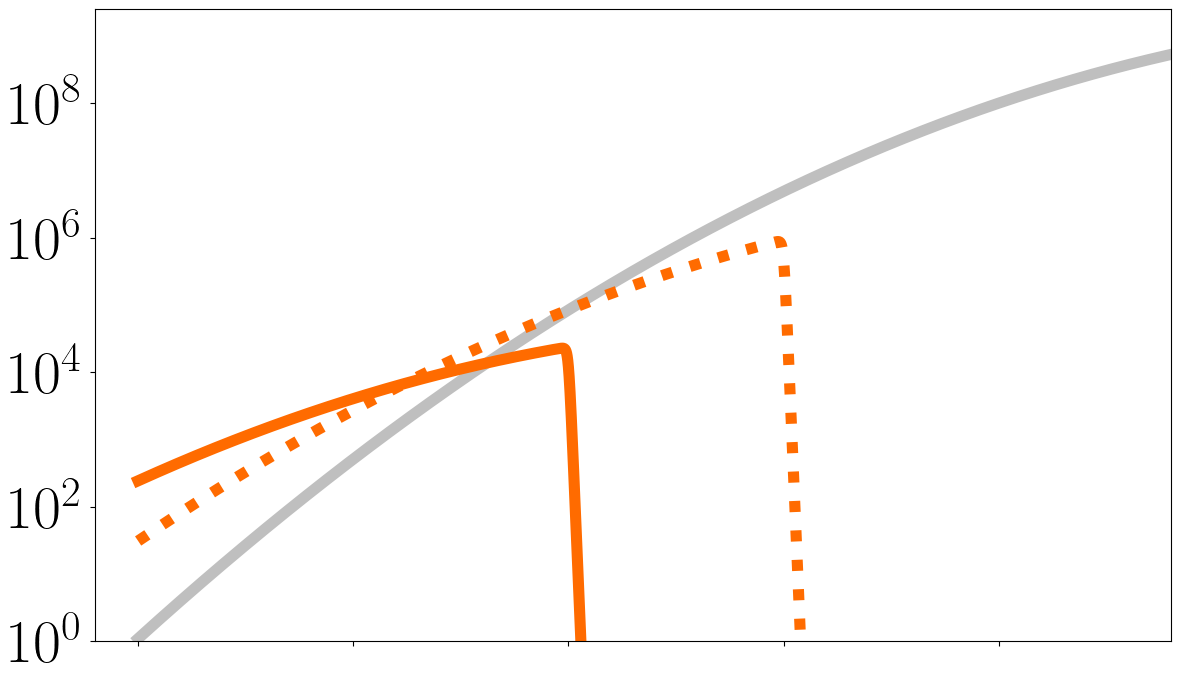

In [3]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
Emax = 12
E = np.linspace(0, Emax, 10000)
Ef = 5
Efm = 7.5
step = 70

fig, ax = plt.subplots(**fig_kw)
ax.plot(E, 2e9*np.exp(-(E-16)**2/(2*6)), color='grey', alpha = 0.5, lw = 8)
ax.plot(E[E<(Efm+0.2)], 5e6*np.exp(-(E[E<(Efm+0.2)]-(16-4))**2/(2*6)) * (1 + np.exp(step*(E[E<(Efm+0.2)] - Efm)))**-1, color=my_red, alpha = 1.0, lw = 8, ls = ':')
ax.plot(E[E<(Ef+0.2)], 5e4*np.exp(-(E[E<(Ef+0.2)]-(16-8))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_red, alpha = 1.0, lw = 8)
# ax.plot(E[E<(Ef+0.2)], 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_blue, alpha = 0.9, lw = 8)
# ax.plot(E[E<(Ef+0.2)] + 2.5, 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_cyan, alpha = 0.9, lw = 8)
# ax.plot(E[E<6] + 2.5, 1e4*np.exp(-1.*E[E<6]), color=my_cyan, alpha = 1.0, lw = 5)
# ax.set_xticks(np.linspace(0, Emax, Emax//2+1), [r"$%.1f$"%i for i in np.linspace(0, Emax, Emax//2+1)]);
ax.tick_params(axis='y', which='both', labelsize=44, labelleft=True)
ax.tick_params(axis='x', labelsize=44, labelbottom=False)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=Emax)
fig.savefig(output_plot + 'naive_null.pdf', dpi=200, transparent=True);

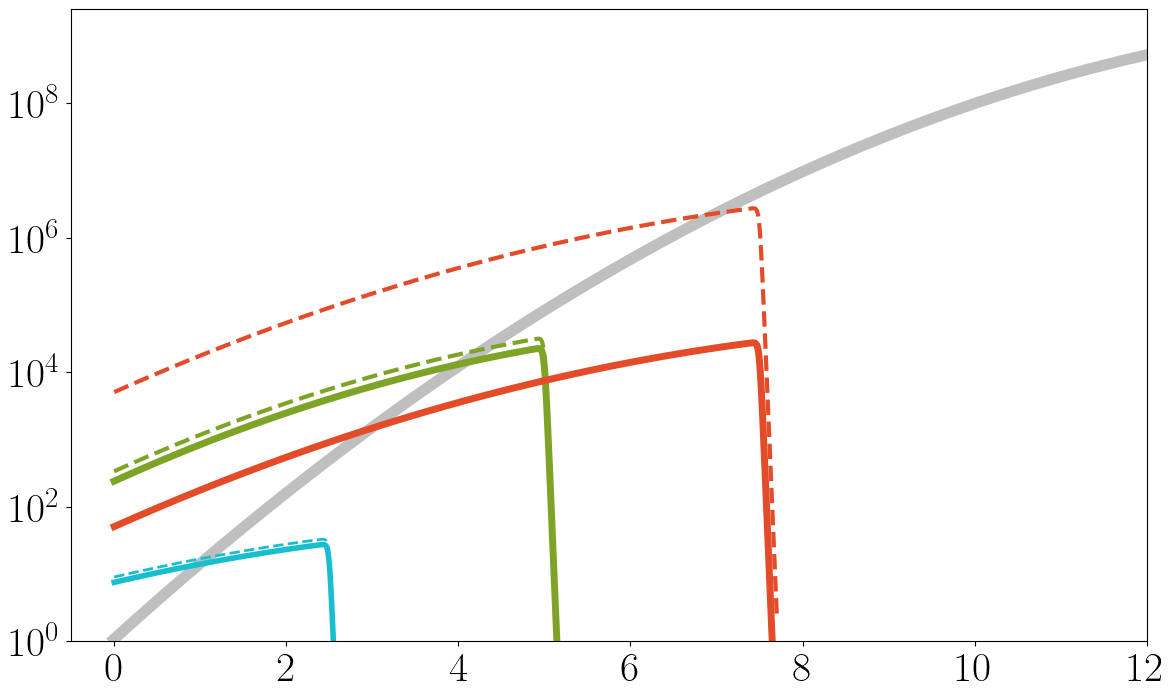

In [11]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
Emax = 12
E = np.linspace(0, Emax, 10000)
E2 = np.linspace(-3, Emax, 10000)
Ef = 5
Efm = 4.5
step = 70
colors_h0 = [my_brown, my_red, my_purple2, my_green, my_blue, my_cyan]

fig, ax = plt.subplots(**fig_kw)
ax.plot(E, 2e9*np.exp(-(E-16)**2/(2*6)), color='grey', alpha = 0.5, lw = 8)
ax.plot(E[E<(Ef+0.2)], 7e4*np.exp(-(E[E<(Ef+0.2)]-(16-8))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_green, alpha = 1.0, lw = 3, ls = '--')
ax.plot(E[E<(Ef+0.2)], 5e4*np.exp(-(E[E<(Ef+0.2)]-(16-8))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_green, alpha = 1.0, lw = 5, ls = '-')
# ax.plot(E2[E2<(Ef+0.2)]+3, 5e7*np.exp(-(E2[E2<(Ef+0.2)]-(16-8))**2/(2*6)) * (1 + np.exp(step*(E2[E2<(Ef+0.2)] - Ef)))**-1, color='green', alpha = 0.9, lw = 8, ls = '--')
ax.plot(E2[(E2<(Ef+0.2)) & (E2>-2.5)]+2.5, 5e6*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>-2.5)]-(16-8))**2/(2*8)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>-2.5)] - Ef)))**-1, color=colors_h0[1], alpha = 1.0, lw = 3, ls = '--')
ax.plot(E2[(E2<(Ef+0.2)) & (E2>-2.5)]+2.5, 5e4*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>-2.5)]-(16-8))**2/(2*8)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>-2.5)] - Ef)))**-1, color=colors_h0[1], alpha = 1.0, lw = 5, ls = '-')
# ax.plot(E2[(E2<(Ef+0.2)) & (E2>-1.25)]+1.25, 5e4*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>-1.25)]-(16-8))**2/(2*8)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>-1.25)] - Ef)))**-1, color=colors_h0[2], alpha = 1.0, lw = 4, ls = '-')
# ax.plot(E2[(E2<(Ef+0.2)) & (E2>1.25)]-1.25, 5e2*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>1.25)]-(16-8))**2/(2*8)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>1.25)] - Ef)))**-1, color=colors_h0[4], alpha = 1.0, lw = 4, ls = '-')
ax.plot(E2[(E2<(Ef+0.2)) & (E2>2.5)]-2.5, 6e1*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>2.5)]-(16-8))**2/(2*8)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>2.5)] - Ef)))**-1, color=colors_h0[5], alpha = 1.0, lw = 2, ls = '--')
ax.plot(E2[(E2<(Ef+0.2)) & (E2>2.5)]-2.5, 5e1*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>2.5)]-(16-8))**2/(2*8)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>2.5)] - Ef)))**-1, color=colors_h0[5], alpha = 1.0, lw = 4, ls = '-')

# ax.plot(E[E<(Ef+0.2)] + 2.5, 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_cyan, alpha = 0.9, lw = 8)
# ax.plot(E[E<6] + 2.5, 1e4*np.exp(-1.*E[E<6]), color=my_cyan, alpha = 1.0, lw = 5)
# ax.set_xticks(np.linspace(0, Emax, Emax//2+1), [r"$%.1f$"%i for i in np.linspace(0, Emax, Emax//2+1)]);
ax.tick_params(axis='y', which='both', labelsize=30, labelleft=True)
ax.tick_params(axis='x', labelsize=30, labelbottom=True)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=Emax)
fig.savefig(output_plot + 'naive_pi_c.pdf', dpi=200, transparent=True);

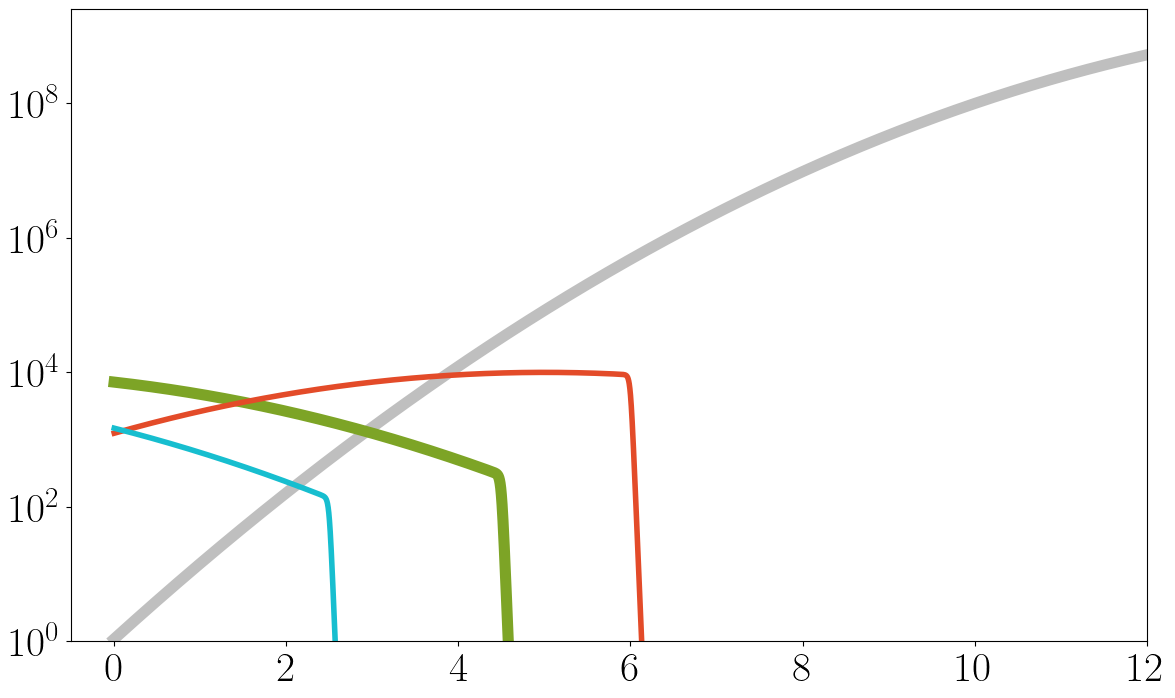

In [12]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
Emax = 12
E = np.linspace(0, Emax, 10000)
E2 = np.linspace(-3, Emax, 10000)
Ef = 5
Efm = 4.5
step = 70
colors_h0 = [my_brown, my_red, my_purple2, my_green, my_blue, my_cyan]

fig, ax = plt.subplots(**fig_kw)
ax.plot(E, 2e9*np.exp(-(E-16)**2/(2*6)), color='grey', alpha = 0.5, lw = 8, ls = '-')
ax.plot(E[E<(Efm+0.2)], 1e4*np.exp(-(E[E<(Efm+0.2)]-(-2))**2/(2*6)) * (1 + np.exp(step*(E[E<(Efm+0.2)] - Efm)))**-1, color=my_green, alpha = 1.0, lw = 8)
# ax.plot(E2[E2<(Ef+0.2)]+3, 5e7*np.exp(-(E2[E2<(Ef+0.2)]-(16-8))**2/(2*6)) * (1 + np.exp(step*(E2[E2<(Ef+0.2)] - Ef)))**-1, color='green', alpha = 0.9, lw = 8, ls = '--')
ax.plot(E2[(E2<(Ef+0.2)) & (E2>-1.0)]+1.0, 1e4*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>-1.0)]-(4.0))**2/(2*6)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>-1.0)] - Ef)))**-1, color=colors_h0[1], alpha = 1.0, lw = 4, ls = '-')
# ax.plot(E2[(E2<(Ef+0.2)) & (E2>-0.0)]+0.0, 5e3*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>-0.0)]-(4.0))**2/(2*6)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>-0.0)] - Ef)))**-1, color=colors_h0[2], alpha = 1.0, lw = 4, ls = '-')
# ax.plot(E2[(E2<(Ef+0.2)) & (E2>1.25)]-1.25, 8e3*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>1.25)]-(-2))**2/(2*6)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>1.25)] - Ef)))**-1, color=colors_h0[4], alpha = 1.0, lw = 4, ls = '-')
ax.plot(E2[(E2<(Ef+0.2)) & (E2>2.5)]-2.5, 8e3*np.exp(-(E2[(E2<(Ef+0.2)) & (E2>2.5)]-(-2))**2/(2*6)) * (1 + np.exp(step*(E2[(E2<(Ef+0.2)) & (E2>2.5)] - Ef)))**-1, color=colors_h0[5], alpha = 1.0, lw = 4, ls = '-')

# ax.plot(E[E<(Ef+0.2)] + 2.5, 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_cyan, alpha = 0.9, lw = 8)
# ax.plot(E[E<6] + 2.5, 1e4*np.exp(-1.*E[E<6]), color=my_cyan, alpha = 1.0, lw = 5)
# ax.set_xticks(np.linspace(0, Emax, Emax//2+1), [r"$%.1f$"%i for i in np.linspace(0, Emax, Emax//2+1)]);
ax.tick_params(axis='y', which='both', labelsize=30, labelleft=True)
ax.tick_params(axis='x', labelsize=30, labelbottom=True)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=Emax)
fig.savefig(output_plot + 'memory_pi_c.pdf', dpi=200, transparent=True);

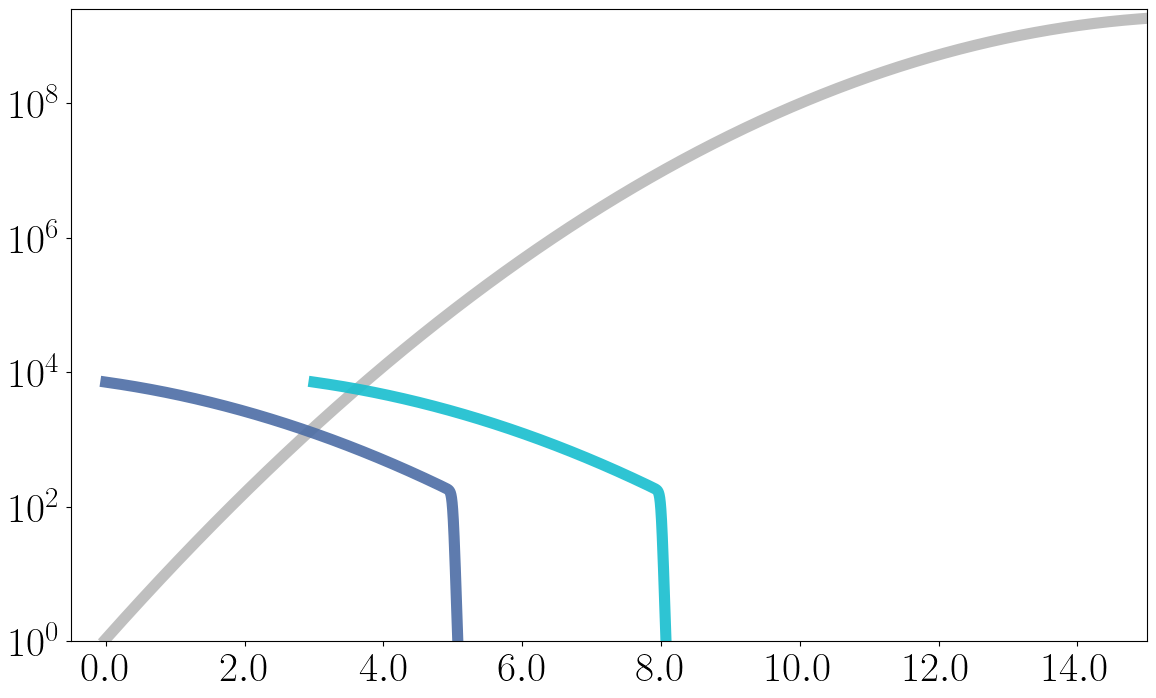

In [ ]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
Emax = 16
E = np.linspace(0, Emax, 10000)
Ef = 5
step = 70

fig, ax = plt.subplots(**fig_kw)
ax.plot(E, 2e9*np.exp(-(E-16)**2/(2*6)), color='grey', alpha = 0.5, lw = 8)
ax.plot(E[E<(Ef+0.2)], 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_blue, alpha = 0.9, lw = 8)
ax.plot(E[E<(Ef+0.2)]+3, 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_cyan, alpha = 0.9, lw = 8)
# ax.plot(E[E<(Ef+0.2)] + 2.5, 1e4*np.exp(-(E[E<(Ef+0.2)]-(16-18))**2/(2*6)) * (1 + np.exp(step*(E[E<(Ef+0.2)] - Ef)))**-1, color=my_cyan, alpha = 0.9, lw = 8)
# ax.plot(E[E<6] + 2.5, 1e4*np.exp(-1.*E[E<6]), color=my_cyan, alpha = 1.0, lw = 5)
ax.set_xticks(np.linspace(0, Emax, Emax//2+1), [r"$%.1f$"%i for i in np.linspace(0, Emax, Emax//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
ax.set_yscale('log')
ax.set_ylim(top=2.5e9, bottom=1)
ax.set_xlim(left=-0.5, right=15)
fig.savefig(output_plot + 'memory_evo.pdf', dpi=200, transparent=True);

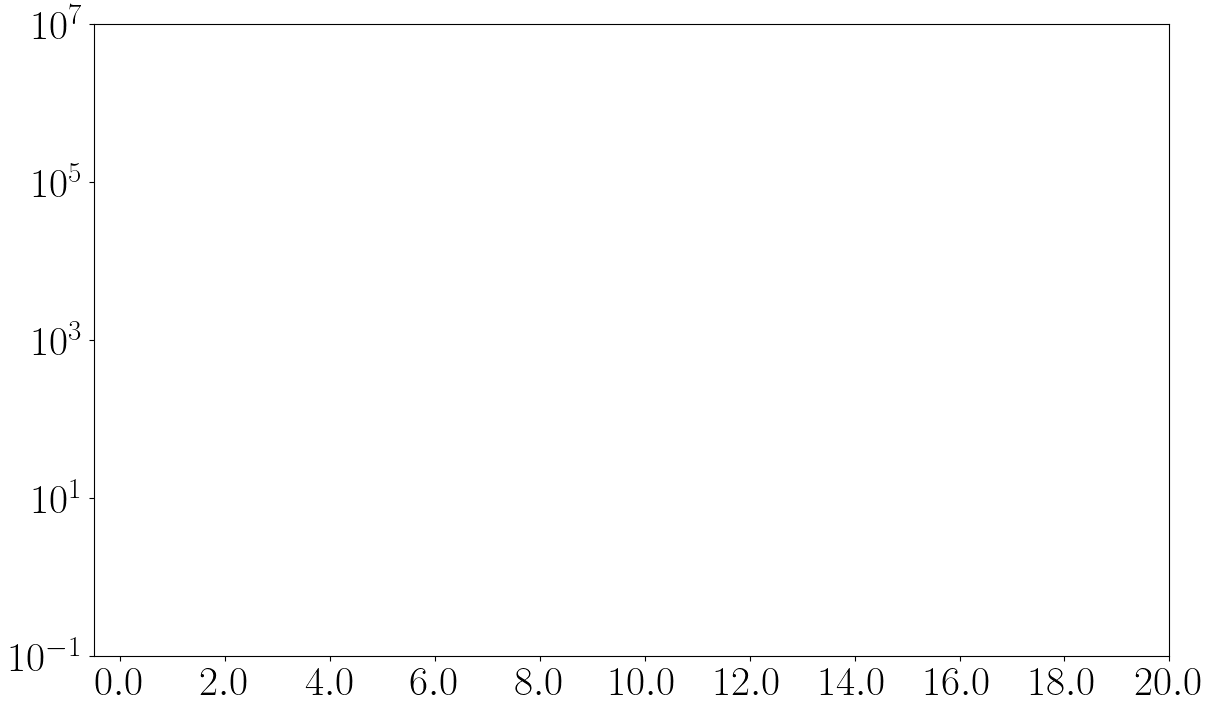

In [29]:
# --- Null model ---
output_plot = '/Users/robertomorantovar/Dropbox/_Documents/Research/Projects/Immune_System/_Repository/Figures/exponential_proofreading/graphics_potency_info/'
os.makedirs(output_plot, exist_ok=True)
mu0 = 0;
n_bars = 20
sigmaE = np.sqrt(6.);
barz0 = np.exp(-mu0 + sigmaE**2/2);
barz = lambda x: barz0*np.exp(sigmaE*np.sqrt(2*x))
D = np.linspace(0, 20, 1000)

fig, ax = plt.subplots(**fig_kw)
# for Z in np.logspace(2, 14, 15):
    # ax.plot(D, Z/barz(D), lw = 2, color='grey', alpha = 0.5)
ax.set_xticks(np.linspace(0, n_bars, n_bars//2+1), [r"$%.1f$"%i for i in np.linspace(0, n_bars, n_bars//2+1)]);
ax.tick_params(axis='both', which='major', labelsize=30)
# ax.set_yscale('log')
ax.set_ylim(top=1e7, bottom=1e-1)
ax.set_xlim(left=-0.5, right=20)
fig.savefig(output_plot + 'grid_potency.pdf', dpi=200, transparent=True);

In [ ]:
t = np.linspace(1, 7, 100)
fig, ax = plt.subplots(figsize=(8,5))
ax.hlines(2e4, 0, 7, color='grey', lw=2, ls='--')
ax.plot(t, np.exp(2*(t+2)), lw = 5, color=my_green_a)
ax.plot(t, np.exp(2*t), lw = 5, color=my_blue2)
ax.plot(t, np.exp(6*(0.8)*(t-4)), lw = 5, color=my_brown)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_yscale('log')
ax.set_ylim(top=1e5, bottom=1)
fig.savefig(output_plot + 'potency_regimes.png', dpi=500, bbox_inches='tight', transparent=True);